# Test Notebook

## Chapter 1 - Stochastic Calculus for Finance I: The Binomial Asset Pricing Model - Steven E. Shreve

**Author:** Daniel González Espinosa

**Year:** 2026

**Binomial Tree Project**

---

### 1. Environment Setup

We prepare the workspace by importing the standard mathematical libraries and the fundamental classes from our local library.

The pricing engine we will test (`ReducedStateEngine`) implements state compression through node recombination. This, combined with a pure polymorphic design for the options (`EuropeanCall`, `LookbackOption`), will allow us to validate Shreve's no-arbitrage and price sensitivity principles while bypassing algorithmic combinatorial explosion.

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from binomial_pricer.lattice import RecombiningLattice
from binomial_pricer.equity_model import BinomialStockModel
from binomial_pricer.payoffs import EuropeanCall, LookbackOption
from binomial_pricer.engines import ReducedStateEngine

print("✅ Environment successfully configured.")
print("✅ Binomial pricing classes imported successfully.")

✅ Environment successfully configured.
✅ Binomial pricing classes imported successfully.


### 2. No-Arbitrage Condition (Ref: Shreve Exercise 1.1)

The first pillar of the binomial model is to ensure that the mathematical configuration of the market does not allow for "riskless profits," that is, it excludes arbitrage. For a model with an up factor $u$, a down factor $d$, and a risk-free interest rate $r$, the fundamental pricing theorem strictly requires that

$$0 < d < 1+r < u.$$

If we violate these analytical boundaries, the market structure collapses financially:

* **If $d \geq 1+r$:** Arbitrage exists by borrowing money from the bank at rate $r$ to invest it entirely in the stock, guaranteeing a net profit.
* **If $u \leq 1+r$:** Arbitrage exists by short-selling the stock to deposit the capital in the bank at rate $r$.

Below, we computationally visualize the valid parameter space for a rate $r$ of 5%.

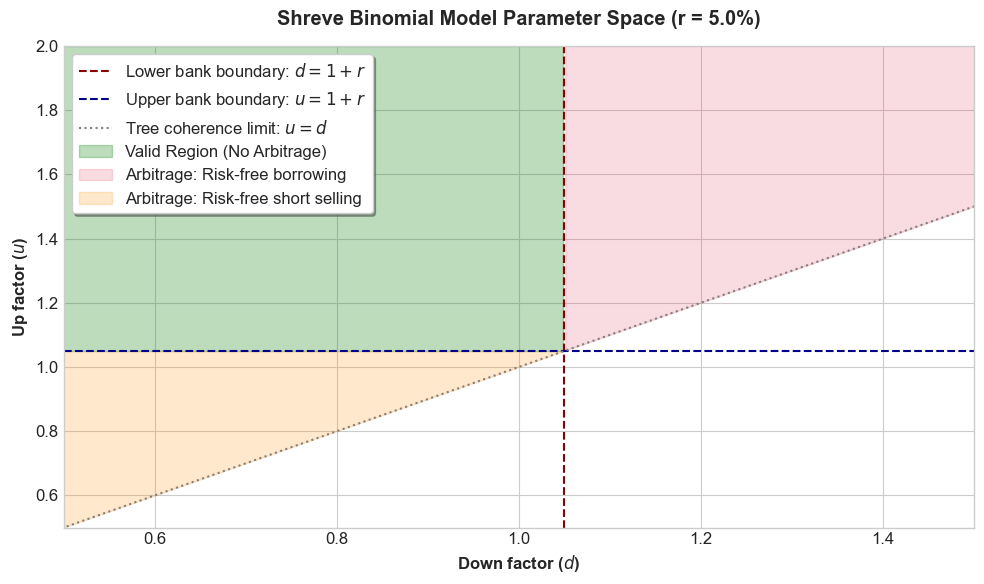

Architecture stress test (Arbitrage Boundaries):
✅ Successful arbitrage block: Arbitrage condition violated: d (1.1) >= 1+r (1.05). 


In [7]:
r = 0.05
risk_free_threshold = 1 + r

d_values = np.linspace(0.1, 1.5, 500)
u_max = 2.0

fig, ax = plt.subplots()

ax.axvline(x=risk_free_threshold, color='darkred', linestyle='--',
label=r'Lower bank boundary: $d = 1+r$')
ax.axhline(y=risk_free_threshold, color='darkblue', linestyle='--',
label=r'Upper bank boundary: $u = 1+r$')
ax.plot([0.1, u_max], [0.1, u_max], color='gray', linestyle=':',
label=r'Tree coherence limit: $u = d$')

ax.fill_between(d_values, risk_free_threshold, u_max,
where=(d_values < risk_free_threshold),
color='forestgreen', alpha=0.3,
label='Valid Region (No Arbitrage)')

ax.fill_between(d_values, d_values, u_max,
where=(d_values >= risk_free_threshold),
color='crimson', alpha=0.15,
label='Arbitrage: Risk-free borrowing')

ax.fill_between(d_values, d_values, risk_free_threshold,
where=(d_values < risk_free_threshold),
color='darkorange', alpha=0.2,
label='Arbitrage: Risk-free short selling')

ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 2.0)
ax.set_xlabel('Down factor ($d$)', fontweight='bold')
ax.set_ylabel('Up factor ($u$)', fontweight='bold')
ax.set_title(f'Shreve Binomial Model Parameter Space (r = {r*100}%)',
fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

print("Architecture stress test (Arbitrage Boundaries):")

try:
    invalid_model = BinomialStockModel(S0=100, u=1.20, d=1.10, r=0.05)
except ValueError as e:
    print(f"✅ Successful arbitrage block: {e}")

### 3. The Risk-Neutral Probability Measure ($\tilde{p}$)

The core of Shreve's pricing theorem lies in the construction of a risk-neutral probability measure ($\tilde{p}$).

The fundamental equation for the probability of an upward trajectory in the binomial model is

$$\tilde{p} = \frac{1+r-d}{u-d}.$$

It is crucial to observe that the historical or real probability of the market going up ($p$) does not appear in this formula. The price of a derivative does not depend on our expectations about the market direction, but solely on the no-arbitrage structure dictated by $u$, $d$, and $r$.

Next, we fix the volatility of the underlying asset (through $u$ and $d$) and evaluate how $\tilde{p}$ evolves against variations in the interest rate $r$. To maintain mathematical consistency, $r$ will vary strictly within the no-arbitrage limits ($d < 1+r < u$).

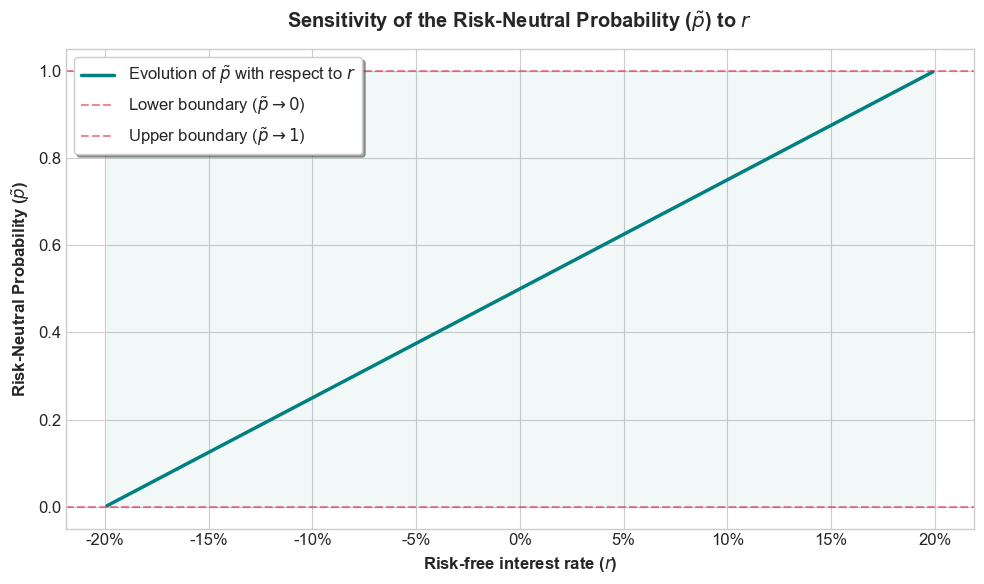

In [8]:
u = 1.20  
d = 0.80  

r_min = d - 1
r_max = u - 1

epsilon = 0.001
r_values = np.linspace(r_min + epsilon, r_max - epsilon, 200)


p_tilde_values = []
for r_val in r_values:
    test_model = BinomialStockModel(S0=100.0, u=u, d=d, r=r_val)
    
    p_tilde, q_tilde = test_model.risk_neutral_prob
    p_tilde_values.append(p_tilde)

fig, ax = plt.subplots()

ax.plot(r_values, p_tilde_values, color='teal', linewidth=2.5, 
        label=r'Evolution of $\tilde{p}$ with respect to $r$')

ax.axhline(y=0, color='crimson', linestyle='--', alpha=0.5, 
           label=r'Lower boundary ($\tilde{p} \to 0$)')
ax.axhline(y=1, color='crimson', linestyle='--', alpha=0.5, 
           label=r'Upper boundary ($\tilde{p} \to 1$)')

ax.fill_between(r_values, 0, 1, color='teal', alpha=0.05)

ax.set_title(r'Sensitivity of the Risk-Neutral Probability ($\tilde{p}$) to $r$', 
             fontweight='bold', pad=15)
ax.set_xlabel('Risk-free interest rate ($r$)', fontweight='bold')
ax.set_ylabel(r'Risk-Neutral Probability ($\tilde{p}$)', fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 4. Price Sensitivity and Delta Hedging ($\Delta$)

Having demonstrated the consistency of the theoretical boundaries (no-arbitrage and the risk-neutral measure), we proceed to instantiate the core architecture of our `binomial_pricer` library.

According to Shreve's fundamental pricing theorem, the price of a derivative $V_0$ is determined by calculating the discounted expected value under the measure $\tilde{p}$. Simultaneously, the model allows us to calculate the exact position in the underlying asset $\Delta_0$ that forms the replicating portfolio and neutralizes market risk. The Delta sensitivity at the initial node is defined by the discrete derivative

$$\Delta_0 = \frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}.$$

We couple `BinomialStockModel` with `ReducedStateEngine` to price a family of `EuropeanCall` options across a spectrum of strike prices ($K$). We will analyze the option's transition from a highly favorable exercise state to an unfavorable exercise state, evaluating how the price decays and how its initial hedge ratio adjusts.

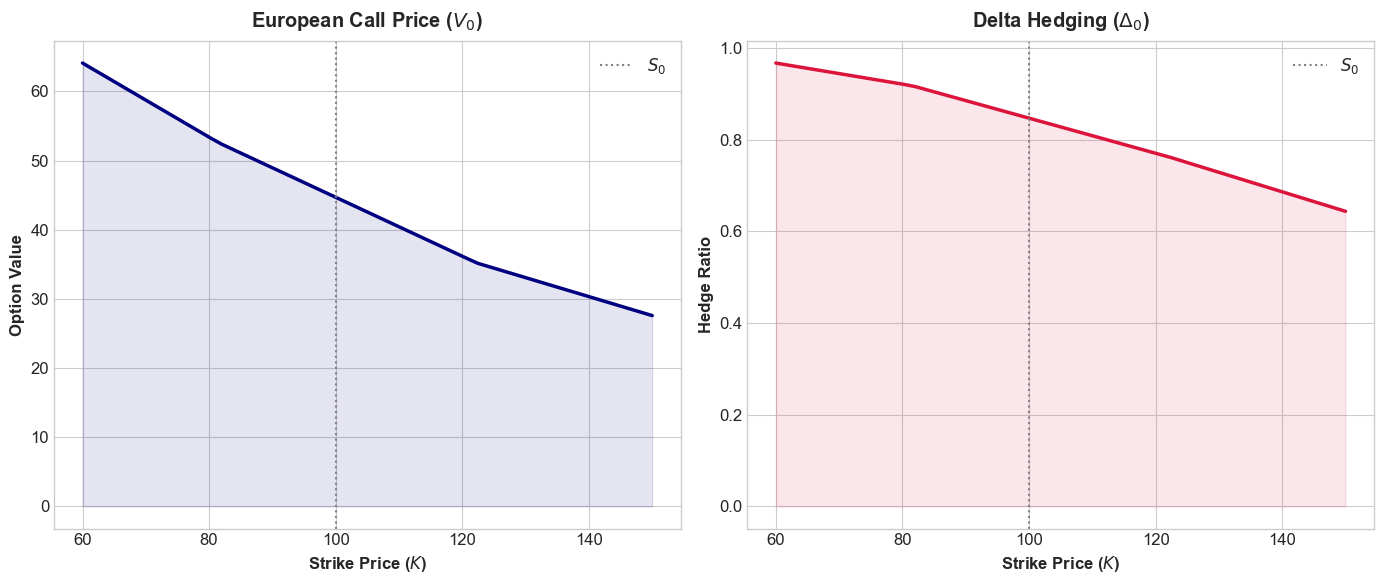

In [9]:
S0 = 100.0   
u = 1.20     
d = 0.80     
r = 0.05    
N = 10       

stock_model = BinomialStockModel(S0, u, d, r)

pricing_engine = ReducedStateEngine()

strikes = np.linspace(60, 150, 50)
prices_V0 = []
deltas_0 = []

for K in strikes:

    european_call = EuropeanCall(strike=K)

    result = pricing_engine.price(model=stock_model, payoff=european_call, n_periods=N)
    
    prices_V0.append(result.v0)
    deltas_0.append(result.delta0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(strikes, prices_V0, color='navy', linewidth=2.5)
ax1.axvline(x=S0, color='gray', linestyle=':', label='$S_0$')
ax1.set_title(r'European Call Price ($V_0$)', fontweight='bold', pad=10)
ax1.set_xlabel('Strike Price ($K$)', fontweight='bold')
ax1.set_ylabel('Option Value', fontweight='bold')
ax1.fill_between(strikes, prices_V0, color='navy', alpha=0.1)
ax1.legend()

ax2.plot(strikes, deltas_0, color='crimson', linewidth=2.5)
ax2.axvline(x=S0, color='gray', linestyle=':', label='$S_0$')
ax2.set_title(r'Delta Hedging ($\Delta_0$)', fontweight='bold', pad=10)
ax2.set_xlabel('Strike Price ($K$)', fontweight='bold')
ax2.set_ylabel('Hedge Ratio', fontweight='bold')
ax2.fill_between(strikes, deltas_0, color='crimson', alpha=0.1)
ax2.legend()

plt.tight_layout()
plt.show()

### 5. The Path Challenge: Lookback vs. Asian Options

When introducing path-dependent options, the risk-neutral pricing principle requires expanding our state space. It is no longer enough to know the current price of the underlying ($S_n$); we need an additional state variable, $m$, that captures the relevant historical information of the path.

This project defines this transition through the abstract interface `PathDependentPayoff`, delegating to the derived class the definition of the methods `initial_aggregate()`, `update_aggregate()`, and `terminal_value()`. However, the nature of $m$ dictates whether the binomial tree is computationally tractable:

1. **Lookback Option:**
For a Lookback option, the state variable is the historical maximum: $M_n = \max_{0 \le i \le n} S_i$. In a tree where the up and down factors are constant ($u, d$), the price $S_n$ takes discrete values on a grid (lattice). Consequently, multiple paths that converge to the same price $S_n$ also share the same maximum $M_n$. This convergence allows our `ReducedStateEngine` to collapse redundant branches, keeping the algorithmic complexity manageable.
2. **Arithmetic Asian Option (The sum does not recombine):**
For a standard Asian option, the state variable is the accumulated sum: $Y_n = \sum_{i=0}^n S_i$. Unlike the maximum, the exact order in which the ups and downs occur alters the value of the intermediate prices and, therefore, alters the total sum. For example, an (Up, Down) path versus a (Down, Up) path ends at the same $S_2$, but generates a different $Y_2$. Since almost no paths share the same $Y_n$, the tree does not recombine, and the number of states grows at an unsustainable rate of $O(2^N)$.

Below, we validate the tractability of the Lookback option. We take $N=15$ and analyze the generated keys (`StateKey`) to demonstrate the state reduction compared to brute-force enumeration.

In [10]:
S0 = 100.0
u = 1.20
d = 0.80
r = 0.05
N = 15  

stock_model = BinomialStockModel(S0, u, d, r)
lookback_option = LookbackOption()
reduced_engine = ReducedStateEngine()

lookback_result = reduced_engine.price(model=stock_model, payoff=lookback_option, n_periods=N)

states_n15 = [key for key in lookback_result.value_grid.keys() if key[0] == N]
num_real_states = len(states_n15)
total_paths = 2 ** N

print("=== COMPLEXITY ANALYSIS (N = 15) ===")
print(f"Possible paths (Enumeration $O(2^N)$): {total_paths:,}")
print(f"Unique computed states at n=15:            {num_real_states:,}")
print(f"Algorithm compression factor:           {total_paths / num_real_states:.2f}x\n")

print("=== STATE CONVERGENCE DEMONSTRATION ===")
s_intermediate = S0 * (u**8) * (d**7)

states_same_spot = [
    key for key in states_n15 
    if np.isclose(key[1], s_intermediate)
]

states_same_spot.sort(key=lambda x: x[2])

print(f"Reaching the final price S_15 = {s_intermediate:.2f}, the tree only records the following states:")
for n, s, m in states_same_spot:
    print(f" -> Key: (n={n}, S_n={s:.2f}, Maximum={m:.2f})")

print(f"\nConclusion: Out of the thousands of paths that end at S_15 = {s_intermediate:.2f}, ")
print(f"the history of maximums ('m') converges into only {len(states_same_spot)} distinct variations.")

=== COMPLEXITY ANALYSIS (N = 15) ===
Possible paths (Enumeration $O(2^N)$): 32,768
Unique computed states at n=15:            210
Algorithm compression factor:           156.04x

=== STATE CONVERGENCE DEMONSTRATION ===
Reaching the final price S_15 = 90.17, the tree only records the following states:
 -> Key: (n=15, S_n=90.17, Maximum=100.00)
 -> Key: (n=15, S_n=90.17, Maximum=101.92)
 -> Key: (n=15, S_n=90.17, Maximum=106.17)
 -> Key: (n=15, S_n=90.17, Maximum=110.59)
 -> Key: (n=15, S_n=90.17, Maximum=112.72)
 -> Key: (n=15, S_n=90.17, Maximum=115.20)
 -> Key: (n=15, S_n=90.17, Maximum=117.41)
 -> Key: (n=15, S_n=90.17, Maximum=120.00)
 -> Key: (n=15, S_n=90.17, Maximum=122.31)
 -> Key: (n=15, S_n=90.17, Maximum=127.40)
 -> Key: (n=15, S_n=90.17, Maximum=132.71)
 -> Key: (n=15, S_n=90.17, Maximum=138.24)
 -> Key: (n=15, S_n=90.17, Maximum=140.90)
 -> Key: (n=15, S_n=90.17, Maximum=144.00)
 -> Key: (n=15, S_n=90.17, Maximum=146.77)
 -> Key: (n=15, S_n=90.17, Maximum=152.88)
 -> Key: (

### 6. Complexity Analysis: $O(2^N)$ vs $O(N^2)$

Derivative pricing via binomial trees faces an insurmountable computational wall if implemented naively. The `RecombiningLattice` class, through its `enumerate_paths()` method, represents the purely combinatorial approach of the iterative process. For a number of periods $N$, the engine must evaluate $2^N$ possible sequences. This makes the model mathematically correct, but algorithmically intractable for any sufficiently large $N$.

In contrast, the object-oriented architecture of the `ReducedStateEngine` implements the state space compression described by Shreve. By recognizing that in a standard tree the number of distinct price nodes at time $n$ is $n+1$, the space and time complexity for path-independent options (such as the European Call) is reduced to an order of $O(N^2)$.

Below, we will perform a computational performance analysis by subjecting our engine to a stress test with increasing values of $N$ (up to 1000 periods). This will demonstrate how state abstraction transforms an unsolvable exponential problem into a computation that finishes in fractions of a second.

Evaluating ReducedStateEngine (European Call)...

 -> Depth N =   10 | Time: 0.000576 seconds
 -> Depth N =   50 | Time: 0.008631 seconds
 -> Depth N =  100 | Time: 0.045289 seconds
 -> Depth N =  250 | Time: 0.175726 seconds
 -> Depth N =  500 | Time: 0.721894 seconds
 -> Depth N = 1000 | Time: 3.015488 seconds


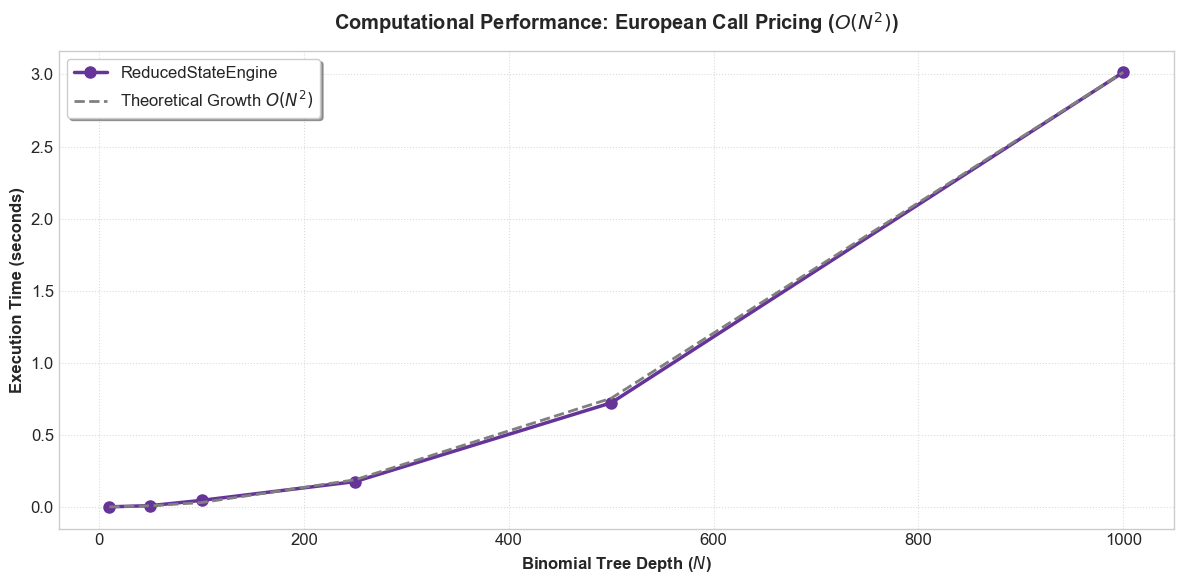

In [11]:
S0 = 100.0
u = 1.20
d = 0.80
r = 0.05

stock_model = BinomialStockModel(S0, u, d, r)
european_call = EuropeanCall(strike=100.0)
reduced_engine = ReducedStateEngine()

N_values = [10, 50, 100, 250, 500, 1000]
execution_times = []

print("Evaluating ReducedStateEngine (European Call)...\n")

for N in N_values:
    start = time.perf_counter()
    
    _ = reduced_engine.price(model=stock_model, payoff=european_call, n_periods=N)
    
    end = time.perf_counter()
    elapsed_time = end - start
    execution_times.append(elapsed_time)
    
    print(f" -> Depth N = {N:4d} | Time: {elapsed_time:.6f} seconds")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(N_values, execution_times, marker='o', color='rebeccapurple', 
        linewidth=2.5, markersize=8, label='ReducedStateEngine')

scale_factor = execution_times[-1] / (N_values[-1] ** 2)
theoretical_times_n2 = [scale_factor * (n ** 2) for n in N_values]

ax.plot(N_values, theoretical_times_n2, color='gray', linestyle='--', 
        linewidth=2, label=r'Theoretical Growth $O(N^2)$')

ax.set_title(r'Computational Performance: European Call Pricing ($O(N^2)$)', 
             fontweight='bold', pad=15)
ax.set_xlabel('Binomial Tree Depth ($N$)', fontweight='bold')
ax.set_ylabel('Execution Time (seconds)', fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()